In [1]:
#all imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
#loading cleaned data
DATA_PATH = Path("../data/cleaned/cyberguard_text_dataset.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df["cyberguard_label"].value_counts())

Dataset shape: (163924, 4)

Columns:
['text', 'cyberguard_label', 'source_dataset', 'source_label']

Class distribution:
cyberguard_label
1    85450
0    78474
Name: count, dtype: int64


In [3]:
#prepareing x, y
X = df["text"].fillna("").astype(str)
y = df["cyberguard_label"]

print("Samples:", len(X))
print("Features:", X.name)
print("Target:", y.name)

Samples: 163924
Features: text
Target: cyberguard_label


In [4]:
#training the test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training samples: 131139
Testing samples : 32785

Training distribution:
cyberguard_label
1    52.13
0    47.87
Name: proportion, dtype: float64

Testing distribution:
cyberguard_label
1    52.13
0    47.87
Name: proportion, dtype: float64


In [6]:
#TF-IDF vectorization
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=200000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (131139, 200000)
Testing TF-IDF shape : (32785, 200000)


In [7]:
#training the logistic regression
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


In [8]:
#making predictions
y_pred = model.predict(X_test_tfidf)

y_prob = model.predict_proba(X_test_tfidf)[:, 1]

print("Predictions generated.")

Predictions generated.


In [9]:
#evaluating the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== Logistic Regression Results =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

===== Logistic Regression Results =====
Accuracy : 0.9911
Precision: 0.9900
Recall   : 0.9930
F1 Score : 0.9915


In [10]:
#classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Suspicious"]
    )
)


Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     15695
  Suspicious       0.99      0.99      0.99     17090

    accuracy                           0.99     32785
   macro avg       0.99      0.99      0.99     32785
weighted avg       0.99      0.99      0.99     32785



Confusion Matrix:
[[15524   171]
 [  120 16970]]


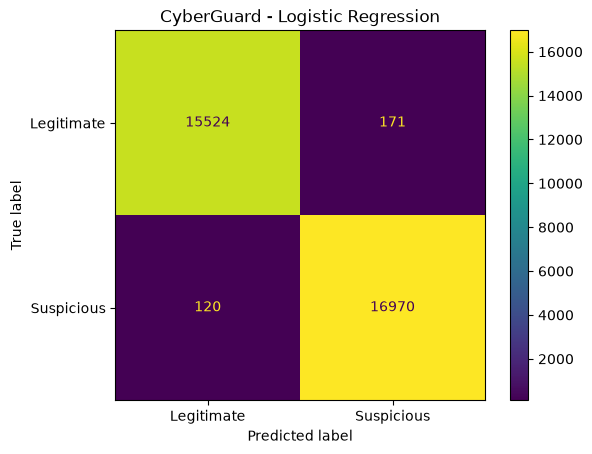

In [11]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Suspicious"]
)

disp.plot()
plt.title("CyberGuard - Logistic Regression")
plt.show()

In [12]:
#model confidence
results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred,
    "suspicious_probability": y_prob
})

results["suspicious_probability"] = (
    results["suspicious_probability"].round(4)
)

results.head(10)

,text,actual,predicted,suspicious_probability
0,Watches for all tastes at Replica Classics onl...,1,1,0.9979
1,nan history ling formigari lia daniele gambara...,0,0,0.0030
2,info cod se voc recebeu essa mensagem signific...,1,1,0.9504
3,inception document for gtv ii phase ii attache...,0,0,0.1258
4,Luxurious costume replica watches at lowest pr...,1,1,0.9972
5,mark brett wiggs is taking el paso through the...,0,0,0.0276
6,o : \\ research \\ exotica access our records ...,0,0,0.0009
7,time may be running out homeowners - do you ha...,1,1,0.9681
8,cnn alerts ulitstemwausaubenefitscom cnn alert...,1,1,0.9957
9,Watches of unexcelled precision Due to the rig...,1,1,0.9690


In [13]:
#sort by highest
results.sort_values(
    "suspicious_probability",
    ascending=False
).head(10)[
    ["actual", "predicted", "suspicious_probability", "text"]
]

,actual,predicted,suspicious_probability,text
19965,1,1,0.9996,Cheap Viagra We are the largest U.S. Company s...
7694,1,1,0.9996,Replica Watches We have fake Swiss Men's and L...
24761,1,1,0.9996,better health online psistjqyclfkkcactivedayto...
1662,1,1,0.9995,Great saving opportunity! Looking for the chea...
27112,1,1,0.9995,Phentermine & Viagra Here We are the largest U...
32229,1,1,0.9995,Quality Replicas We have fake Swiss Men's and ...
28105,1,1,0.9994,bhgb Royal Meds _ y o u r o n l i n e p h a r ...
17988,1,1,0.9994,Looking for a watch? Visit Replica Classics Be...
26797,1,1,0.9994,hot free xxx software ! ! ! > > > > > > > > > ...
25467,1,1,0.9993,antonio washington philipgroutalexandermegatok...


In [14]:
#sort by lowest
results.sort_values(
    "suspicious_probability",
    ascending=True
).head(10)[
    ["actual", "predicted", "suspicious_probability", "text"]
]

,actual,predicted,suspicious_probability,text
32681,0,0,0.0,india model stinson vince please see wade comm...
31414,0,0,0.0,the national forum on corporate finance hello ...
6811,0,0,0.0,wharton hi jeff know received information addi...
25601,0,0,0.0,corporate allocation enron research group disc...
20726,0,0,0.0,latest last sorry found something else p 1 foo...
24195,0,0,0.0,re : visit to enron thanks . i will be flying ...
1650,0,0,0.0,national forum corporate finance hello mr fast...
26031,0,0,0.0,"re : forster , accenture talked to forster yes..."
29315,0,0,0.0,university texas conference energy finance feb...
169,0,0,0.0,aaron kulkis cmiqlkx91hotpopcom james r thomps...


In [15]:
#saving the baseline model
import joblib

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    model,
    MODEL_DIR / "baseline_logistic_regression.pkl"
)

joblib.dump(
    tfidf,
    MODEL_DIR / "baseline_tfidf_vectorizer.pkl"
)

print("Baseline model saved.")

Baseline model saved.


In [16]:
# Build test results while preserving the original dataframe index

test_results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred,
    "probability": y_prob
})

# Recover dataset source
test_results["source_dataset"] = df.loc[
    test_results.index,
    "source_dataset"
]

test_results.head()

,text,actual,predicted,probability,source_dataset
26267,Watches for all tastes at Replica Classics onl...,1,1,0.997905,CEAS_08.csv
106806,nan history ling formigari lia daniele gambara...,0,0,0.003046,phishing_email.csv
103233,info cod se voc recebeu essa mensagem signific...,1,1,0.950357,phishing_email.csv
52000,inception document for gtv ii phase ii attache...,0,0,0.125837,Enron.csv
28162,Luxurious costume replica watches at lowest pr...,1,1,0.997184,CEAS_08.csv


In [17]:
#calculating matrics per source
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

source_results = []

for source, group in test_results.groupby("source_dataset"):

    source_results.append({
        "Dataset": source,
        "Samples": len(group),
        "Accuracy": accuracy_score(
            group["actual"],
            group["predicted"]
        ),
        "Precision": precision_score(
            group["actual"],
            group["predicted"],
            zero_division=0
        ),
        "Recall": recall_score(
            group["actual"],
            group["predicted"],
            zero_division=0
        ),
        "F1": f1_score(
            group["actual"],
            group["predicted"],
            zero_division=0
        )
    })

source_results_df = pd.DataFrame(source_results)

source_results_df.round(4)

,Dataset,Samples,Accuracy,Precision,Recall,F1
0,CEAS_08.csv,7912,0.9937,0.9911,0.9975,0.9943
1,Enron.csv,5852,0.9874,0.9874,0.9852,0.9863
2,Ling.csv,570,0.9912,0.9545,0.9882,0.9711
3,Nazario.csv,296,0.9966,1.0000,0.9966,0.9983
4,Nigerian_Fraud.csv,636,0.9984,1.0000,0.9984,0.9992
5,SpamAssasin.csv,1176,0.9847,0.9615,0.9887,0.9749
6,phishing_email.csv,16343,0.9913,0.9908,0.9928,0.9918


In [18]:
#checking models most difficult cases
false_negatives = test_results[
    (test_results["actual"] == 1) &
    (test_results["predicted"] == 0)
]

print("False negatives:", len(false_negatives))

false_negatives[
    ["source_dataset", "probability", "text"]
].sort_values("probability").head(10)

False negatives: 120


,source_dataset,probability,text
43198,Enron.csv,0.007043,cfp : int . conf . on web delivering of music ...
81265,phishing_email.csv,0.007102,cfp int conf web delivering music wedelmusic 2...
85919,phishing_email.csv,0.028055,call papers international joint conferences co...
96066,phishing_email.csv,0.031485,using ling spam discourse analysis many thanks...
10958,CEAS_08.csv,0.052655,fwvf SALE 47% OFF Food Network Newsletter This...
152695,phishing_email.csv,0.053043,vcqztr_2gk1525deutschebankde éåx ma0åéäïhc x_u...
76008,SpamAssasin.csv,0.064700,An Invitation from Lisa@freightmart.com http:/...
113343,phishing_email.csv,0.084795,user5gvcceaschallengecc food network newslette...
97580,phishing_email.csv,0.123151,southern california demographic analysis works...
65207,Enron.csv,0.133257,post secondary certificates for sale here you ...


In [19]:
#false positives
false_positives = test_results[
    (test_results["actual"] == 0) &
    (test_results["predicted"] == 1)
]

print("False positives:", len(false_positives))

false_positives[
    ["source_dataset", "probability", "text"]
].sort_values("probability", ascending=False).head(10)

False positives: 171


,source_dataset,probability,text
119804,phishing_email.csv,0.989198,pace university evppaceedu messages quarantine...
128715,phishing_email.csv,0.979276,pace university evppaceedu messages quarantine...
125014,phishing_email.csv,0.966783,pace university evppaceedu messages quarantine...
63678,Enron.csv,0.965773,calendar here ' s the site . . . http : / / ww...
101691,phishing_email.csv,0.965773,calendar site http www hemmings com
64234,Enron.csv,0.918958,fw : on the first day subject : on the first d...
134622,phishing_email.csv,0.918843,registrationspsscom thank registering account ...
80282,phishing_email.csv,0.913066,important video announcement important video a...
42213,Enron.csv,0.913066,important video announcement i have a very imp...
112398,phishing_email.csv,0.905208,salesgeniecom upadsalesgenienewscom ensure del...


In [20]:
#saving the baseline properly
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
RESULTS_DIR = Path("../results")

MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

joblib.dump(
    model,
    MODEL_DIR / "baseline_logistic_regression.pkl"
)

joblib.dump(
    tfidf,
    MODEL_DIR / "baseline_tfidf_vectorizer.pkl"
)

source_results_df.to_csv(
    RESULTS_DIR / "baseline_source_metrics.csv",
    index=False
)

print("Baseline artifacts saved successfully.")

Baseline artifacts saved successfully.


In [21]:
# Check for highly similar short/common messages using TF-IDF similarity
# on a manageable sample of the test set.

from sklearn.metrics.pairwise import cosine_similarity

sample_size = min(1000, len(X_test))

sample_indices = X_test.sample(
    sample_size,
    random_state=42
).index

sample_text = X_test.loc[sample_indices]

sample_tfidf = tfidf.transform(sample_text)

similarity = cosine_similarity(sample_tfidf)

# Ignore self-similarity
np.fill_diagonal(similarity, 0)

max_similarity = similarity.max(axis=1)

similarity_results = pd.DataFrame({
    "index": sample_indices,
    "max_similarity_to_test_sample": max_similarity
}).sort_values(
    "max_similarity_to_test_sample",
    ascending=False
)

similarity_results.head(20)

,index,max_similarity_to_test_sample
921,12706,1.0
752,11745,1.0
560,15828,1.0
340,15919,1.0
513,18939,1.0
5,12713,1.0
350,13606,1.0
612,16741,1.0
150,124363,1.0
475,125429,1.0


In [22]:
#linear SVM
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("Linear SVM training completed.")

Linear SVM training completed.


In [23]:
#making prediction using SVM
svm_pred = svm_model.predict(X_test_tfidf)

print("===== Linear SVM Results =====")

print(
    f"Accuracy : {accuracy_score(y_test, svm_pred):.4f}"
)

print(
    f"Precision: {precision_score(y_test, svm_pred):.4f}"
)

print(
    f"Recall   : {recall_score(y_test, svm_pred):.4f}"
)

print(
    f"F1 Score : {f1_score(y_test, svm_pred):.4f}"
)

===== Linear SVM Results =====
Accuracy : 0.9982
Precision: 0.9978
Recall   : 0.9987
F1 Score : 0.9982


In [24]:
#classification report
print(
    classification_report(
        y_test,
        svm_pred,
        target_names=["Legitimate", "Suspicious"]
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     15695
  Suspicious       1.00      1.00      1.00     17090

    accuracy                           1.00     32785
   macro avg       1.00      1.00      1.00     32785
weighted avg       1.00      1.00      1.00     32785



In [25]:
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("===== Linear SVM Exact Results =====")
print(f"Accuracy : {svm_accuracy:.6f}")
print(f"Precision: {svm_precision:.6f}")
print(f"Recall   : {svm_recall:.6f}")
print(f"F1 Score : {svm_f1:.6f}")

svm_cm = confusion_matrix(y_test, svm_pred)

print("\nConfusion Matrix:")
print(svm_cm)

===== Linear SVM Exact Results =====
Accuracy : 0.998170
Precision: 0.997837
Recall   : 0.998654
F1 Score : 0.998245

Confusion Matrix:
[[15658    37]
 [   23 17067]]


In [26]:
tn, fp, fn, tp = svm_cm.ravel()

print("\nError Analysis")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

print("\nFalse Positive Rate:",
      fp / (fp + tn))

print("False Negative Rate:",
      fn / (fn + tp))


Error Analysis
True Negatives : 15658
False Positives: 37
False Negatives: 23
True Positives  : 17067

False Positive Rate: 0.0023574386747371775
False Negative Rate: 0.0013458162668227034


In [27]:
#source wise SVM result
svm_test_results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": svm_pred
})

svm_test_results["source_dataset"] = df.loc[
    svm_test_results.index,
    "source_dataset"
]

svm_source_results = []

for source, group in svm_test_results.groupby("source_dataset"):

    svm_source_results.append({
        "Dataset": source,
        "Samples": len(group),
        "Accuracy": accuracy_score(
            group["actual"],
            group["predicted"]
        ),
        "Precision": precision_score(
            group["actual"],
            group["predicted"],
            zero_division=0
        ),
        "Recall": recall_score(
            group["actual"],
            group["predicted"],
            zero_division=0
        ),
        "F1": f1_score(
            group["actual"],
            group["predicted"],
            zero_division=0
        )
    })

svm_source_results_df = pd.DataFrame(svm_source_results)

svm_source_results_df.round(4)

,Dataset,Samples,Accuracy,Precision,Recall,F1
0,CEAS_08.csv,7912,0.9991,0.9986,0.9998,0.9992
1,Enron.csv,5852,0.9973,0.9974,0.9967,0.9970
2,Ling.csv,570,0.9982,0.9884,1.0000,0.9942
3,Nazario.csv,296,0.9966,1.0000,0.9966,0.9983
4,Nigerian_Fraud.csv,636,1.0000,1.0000,1.0000,1.0000
5,SpamAssasin.csv,1176,0.9966,0.9916,0.9972,0.9944
6,phishing_email.csv,16343,0.9981,0.9977,0.9987,0.9982


In [28]:
from sklearn.metrics.pairwise import cosine_similarity

sample_size = min(1000, len(X_test))

sample_indices = X_test.sample(
    sample_size,
    random_state=42
).index

sample_text = X_test.loc[sample_indices]

sample_tfidf = tfidf.transform(sample_text)

similarity = cosine_similarity(sample_tfidf)

np.fill_diagonal(similarity, 0)

max_similarity = similarity.max(axis=1)

similarity_results = pd.DataFrame({
    "index": sample_indices,
    "max_similarity_to_test_sample": max_similarity
}).sort_values(
    "max_similarity_to_test_sample",
    ascending=False
)

similarity_results.head(20)

,index,max_similarity_to_test_sample
921,12706,1.0
752,11745,1.0
560,15828,1.0
340,15919,1.0
513,18939,1.0
5,12713,1.0
350,13606,1.0
612,16741,1.0
150,124363,1.0
475,125429,1.0


In [29]:
print("Similarity >= 0.90:",
      (similarity_results["max_similarity_to_test_sample"] >= 0.90).sum())

print("Similarity >= 0.80:",
      (similarity_results["max_similarity_to_test_sample"] >= 0.80).sum())

print("Similarity >= 0.70:",
      (similarity_results["max_similarity_to_test_sample"] >= 0.70).sum())

Similarity >= 0.90: 50
Similarity >= 0.80: 69
Similarity >= 0.70: 90


In [30]:
#proper train/test similarity check
from sklearn.metrics.pairwise import cosine_similarity

# Use a manageable test sample
sample_size = min(1000, len(X_test))

sample_indices = X_test.sample(
    sample_size,
    random_state=42
).index

sample_test_text = X_test.loc[sample_indices]

# Transform test samples
test_sample_tfidf = tfidf.transform(sample_test_text)

# Compare test samples against TRAINING data
similarity_to_train = cosine_similarity(
    test_sample_tfidf,
    X_train_tfidf,
    dense_output=False
)

# Highest similarity each test message has with ANY training message
max_train_similarity = similarity_to_train.max(axis=1).toarray().ravel()

train_similarity_results = pd.DataFrame({
    "index": sample_indices,
    "max_similarity_to_train": max_train_similarity
}).sort_values(
    "max_similarity_to_train",
    ascending=False
)

train_similarity_results.head(20)

,index,max_similarity_to_train
665,10453,1.0
750,122298,1.0
881,24333,1.0
887,23828,1.0
352,68293,1.0
329,22470,1.0
262,22805,1.0
148,22110,1.0
332,46577,1.0
29,133437,1.0


In [31]:
print(
    "Similarity >= 0.95:",
    (train_similarity_results["max_similarity_to_train"] >= 0.95).sum()
)

print(
    "Similarity >= 0.90:",
    (train_similarity_results["max_similarity_to_train"] >= 0.90).sum()
)

print(
    "Similarity >= 0.80:",
    (train_similarity_results["max_similarity_to_train"] >= 0.80).sum()
)

print(
    "Similarity >= 0.70:",
    (train_similarity_results["max_similarity_to_train"] >= 0.70).sum()
)

Similarity >= 0.95: 439
Similarity >= 0.90: 541
Similarity >= 0.80: 699
Similarity >= 0.70: 819


In [32]:
high_similarity_indices = train_similarity_results[
    train_similarity_results["max_similarity_to_train"] >= 0.90
]["index"]

for idx in high_similarity_indices[:10]:

    test_text = X_test.loc[idx]

    # Find most similar training message
    test_vector = tfidf.transform([test_text])

    similarities = cosine_similarity(
        test_vector,
        X_train_tfidf,
        dense_output=False
    ).toarray()[0]

    best_train_position = similarities.argmax()
    best_score = similarities[best_train_position]

    train_index = X_train.index[best_train_position]

    print("\n" + "=" * 80)
    print("Similarity:", round(best_score, 4))

    print("\nTEST:")
    print(test_text[:500])

    print("\nTRAIN:")
    print(X_train.loc[train_index][:500])


Similarity: 1.0

TEST:
CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug 1, 2008 3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= TOP 10 VIDEOS 1. MONTAUK 'MONSTER' http://www.cnn.com/video/partners/email/index.html?url=/video/us/2008/07/31/moos.montauk.monster.cnn Is it a devil dog? Is it a turtle? Is it the Montauk Monster? CNN's Jeanne Moos asks, "what is this thing?" 2. RACY PHOTOS OF TODDLE

TRAIN:
CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug 1, 2008 3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= TOP 10 VIDEOS 1. MONTAUK 'MONSTER' http://www.cnn.com/video/partners/email/index.html?url=/video/us/2008/07/31/moos.montauk.monster.cnn Is it a devil dog? Is it a turtle? Is it the Montauk Monster? CNN's Jeanne Moos asks, "what is this

In [33]:
# Count exact duplicate representations between train and test
train_texts = set(X_train)

test_train_exact_overlap = [
    text for text in X_test
    if text in train_texts
]

print(
    "Exact train-test text overlap:",
    len(test_train_exact_overlap)
)

print(
    "Percentage of test set:",
    round(
        len(test_train_exact_overlap) / len(X_test) * 100,
        4
    ),
    "%"
)

Exact train-test text overlap: 0
Percentage of test set: 0.0 %
